In [2]:
import pandas as pd
import matplotlib.pyplot as plt

tweets_df = pd.read_csv("https://raw.githubusercontent.com/KCristopher/SentimentAnalysis/main/sts_gold_tweet.csv")
tweets_df.head()

,id,polarity,tweet
0,1467933112,0,the angel is going to miss the athlete this we...
1,2323395086,0,It looks as though Shaq is getting traded to C...
2,1467968979,0,@clarianne APRIL 9TH ISN'T COMING SOON ENOUGH
3,1990283756,0,drinking a McDonalds coffee and not understand...
4,1988884918,0,So dissapointed Taylor Swift doesnt have a Twi...


In [3]:
tweets_df.shape

(2034, 3)

In [4]:
tweets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2034 entries, 0 to 2033
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        2034 non-null   int64 
 1   polarity  2034 non-null   int64 
 2   tweet     2034 non-null   object
dtypes: int64(2), object(1)
memory usage: 47.8+ KB


In [5]:
tweets_df['id'].nunique(), len(tweets_df)

(2034, 2034)

In [6]:
tweets_df.groupby('id')['tweet'].nunique().sort_values(ascending = False).head(10)

id
1467812416    1
2052262229    1
2053125094    1
2053014136    1
2052945734    1
2052940465    1
2052939840    1
2052859663    1
2052844839    1
2052807447    1
Name: tweet, dtype: int64

In [7]:
( tweets_df.groupby('id')['tweet'].nunique() == 1 ).all()

True

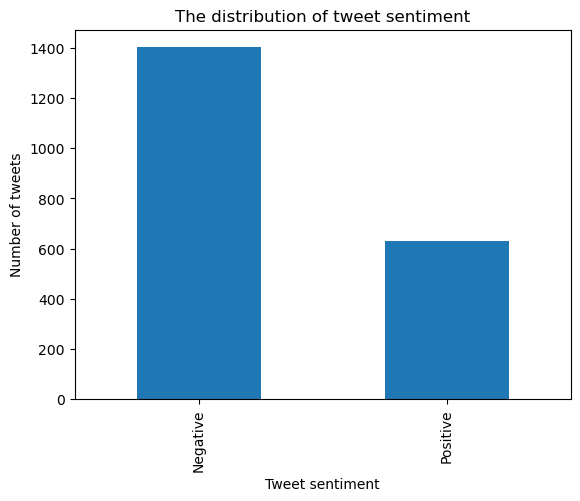

In [8]:
ax = tweets_df['polarity'].value_counts(dropna = False).plot.bar()
plt.title("The distribution of tweet sentiment")
plt.xticks(ax.get_xticks(), ['Negative', 'Positive'])
plt.ylabel('Number of tweets')
plt.xlabel('Tweet sentiment')
plt.show()

In [9]:
sample_tweets = tweets_df[['polarity', 'tweet']].sample(n = 10)

for row in sample_tweets.iterrows() :
    print('\n', row[1]['tweet'], '  >>>>>>>  ', row[1]['polarity'], '\n')


 Great stuff this wk: my bike ride in the wild on Sun.; Obama's speech in Cairo; last episode of Lost 3; Lakers 1st win; my wife's smile    >>>>>>>   4 


 @taylorswift13 @selenagomez @ddlovato Please pray for my friend's dog Mikey, he may has cancer    >>>>>>>   0 


 Argh crap just remembered we go visitors over tonight  wanted to veg out and play xbox.   >>>>>>>   0 


  @iggigg too busy to see me in London this evening. What is a boy to do?   >>>>>>>   0 


 @seodubai Go #Lakers go!  Good morning!   >>>>>>>   4 


 Best &quot;I want to fall in love&quot; song for today: Taylor Swift's Fearless. Ahuhuhu!    >>>>>>>   4 


 I thought you could buy Silent Hill for the PSP on the PS Store? I can't find it anywhere?    >>>>>>>   0 


 i really need a new ipod  i can't fit all my music onto my ipod nano.   >>>>>>>   0 


 almost freaking out cause of this damn headache    >>>>>>>   0 


 Damn @omgk I finally hit 10k and I have been on #xbox for over 3 years    >>>>>>>   0 



In [12]:
tweets_df['tweet_length'] = tweets_df['tweet'].str.len()
tweets_df['tweet_length'].describe().round(2)

count    2034.00
mean       80.81
std        35.36
min        11.00
25%        51.00
50%        77.50
75%       111.00
max       148.00
Name: tweet_length, dtype: float64

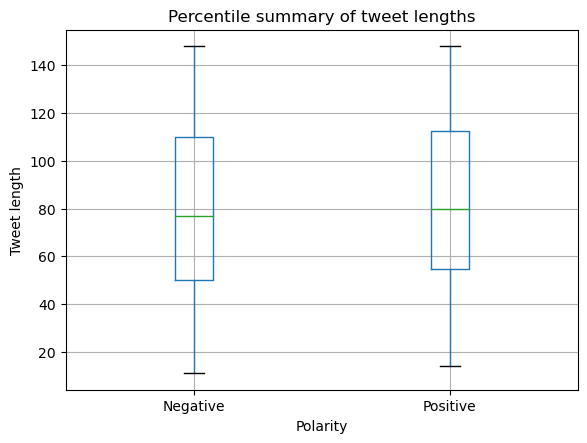

In [18]:
lengths_box = tweets_df.boxplot(column='tweet_length', by='polarity')
plt.suptitle('')
plt.title('Percentile summary of tweet lengths')
plt.xticks( lengths_box.get_xticks(), [ 'Negative', 'Positive' ] )
plt.ylabel('Tweet length')
plt.xlabel('Polarity')

plt.show()